# Cat vs Dog Image Classification using Transfer Learning

This project builds and compares three transfer learning models — **MobileNetV2**, **EfficientNet-B0**, and **ResNet50** — to classify images of cats and dogs. We use pre-trained ImageNet weights, freeze the base layers, and train only the classification head. Models are evaluated using validation accuracy, loss curves, confusion matrices, and ROC AUC curves.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow
import cv2
from google.colab.patches import cv2_imshow

## 2. Download and Extract Dataset

The dataset is downloaded directly from a hosted URL as a zip file, extracted into memory using `BytesIO`, and saved to a local directory without writing the zip to disk first.

In [2]:
from io import BytesIO # provide in memeory binary stream and data stored in ram not disk
from zipfile import ZipFile
import requests

# 1. Provide the direct link to the zip file
url = "https://d3ilbtxij3aepc.cloudfront.net/projects/CNN-PROJECT-7-11/Cats-Dogs-2.zip"
target_directory = "./extracted_files"

# 2. Download the zip file contents
response = requests.get(url)

# 3. Open the zipped content from memory and extract
with ZipFile(BytesIO(response.content)) as zip_file:
    zip_file.extractall(target_directory)

print("Extraction completed successfully!")

Extraction completed successfully!


## 3. Explore Dataset

Count the number of images available for each class to verify the dataset was extracted correctly and check for class balance.

In [3]:
file_list_cat = os.listdir("/content/extracted_files/PetImages/Cat")
file_list_dog = os.listdir("/content/extracted_files/PetImages/Dog")
len_files_cat = len(file_list_cat)
len_files_dog = len(file_list_dog)
print("no of cat images",len_files_cat)
print("no of dog images",len_files_dog)


no of cat images 12501
no of dog images 12501


## 4. Load and Preprocess Images

Each image is read using OpenCV, resized to **150×150 pixels**, and appended to the data list. Corrupted or unreadable files are silently skipped using `try-except` to ensure robust loading. Labels are assigned as `0` for Cat and `1` for Dog.

In [4]:
data = []
labels = []
image_size = 150 # Define a consistent image size for preprocessing

# Define paths for cat and dog images
CAT_DIR = os.path.join(target_directory, 'PetImages', 'Cat')
DOG_DIR = os.path.join(target_directory, 'PetImages', 'Dog')

# Process cat images
for file in os.listdir(CAT_DIR):
    try:
        img_path = os.path.join(CAT_DIR, file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (image_size, image_size))
            data.append(img)
            labels.append(0) # 0 for cat
    except Exception as e:
        print(f"Could not read cat image {file}: {e}")

# Process dog images
for file in os.listdir(DOG_DIR):
    try:
        img_path = os.path.join(DOG_DIR, file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (image_size, image_size))
            data.append(img)
            labels.append(1) # 1 for dog
    except Exception as e:
        print(f"Could not read dog image {file}: {e}")

print(f"Total images processed: {len(data)}")
print(f"Total labels processed: {len(labels)}")

Total images processed: 24997
Total labels processed: 24997


### Sample Image

Display a sample image from the loaded dataset to visually verify the loading and resizing process.

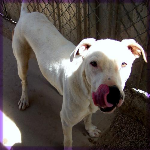

In [5]:
cv2_imshow(data[12498])

## 5. Train / Validation / Test Split

The dataset is split into three subsets:
- **80%** for training
- **10%** for validation (used during training to tune the model)
- **10%** for testing (used for final evaluation)

Note: Image normalization (dividing by 255) is intentionally skipped here. Each model's pre-trained preprocessing layer handles its own input scaling internally, which also avoids creating large duplicate arrays that can exhaust GPU memory.

In [6]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convert lists to NumPy arrays
X = np.array(data)
y = np.array(labels)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the test set further into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

print(f"Training data shape: {X_train.shape}, labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, labels shape: {y_test.shape}")

Training data shape: (19997, 150, 150, 3), labels shape: (19997,)
Validation data shape: (2500, 150, 150, 3), labels shape: (2500,)
Test data shape: (2500, 150, 150, 3), labels shape: (2500,)


## 6. Build Transfer Learning Models

A reusable function `build_transfer_model_for_numpy_input` builds a transfer learning model for any of the three architectures. Key design choices:
- The base model weights are **frozen** so only the classification head is trained.
- Model-specific preprocessing is applied inside the model using `Lambda` layers.
- A `GlobalAveragePooling2D` + `Dropout` + `Dense(1, sigmoid)` head is added for binary classification.

Common callbacks — **EarlyStopping** and **ReduceLROnPlateau** — are defined once and shared across all models.

In [7]:
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Common Callbacks ---
# Define EarlyStopping and ReduceLROnPlateau once, as they are general
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

# --- Model Building Function (Reusable) ---
def build_transfer_model_for_numpy_input(base_model_name, input_shape, dropout_rate=0.2, learning_rate=0.001):
    """Builds a transfer learning model with a specified base architecture for NumPy inputs."""

    inputs = Input(shape=input_shape)
    # Cast input images to float32, as application models typically expect float input
    x = Lambda(lambda image: tf.cast(image, tf.float32))(inputs)

    # --- Model-specific preprocessing and base model loading ---
    if base_model_name == 'MobileNetV2':
        # MobileNetV2 expects input in the range [-1, 1]
        x = Lambda(tf.keras.applications.mobilenet_v2.preprocess_input)(x)
        base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    elif base_model_name == 'EfficientNetB0':
        # EfficientNetB0 expects input to be scaled to [-1, 1]
        x = Lambda(tf.keras.applications.efficientnet.preprocess_input)(x)
        base_model = EfficientNetB0(input_shape=input_shape, include_top=False, weights='imagenet')
    elif base_model_name == 'ResNet50':
        # ResNet50 expects input to be scaled to [-1, 1] or specific mean/std scaling
        x = Lambda(tf.keras.applications.resnet50.preprocess_input)(x)
        base_model = ResNet50(input_shape=input_shape, include_top=False, weights='imagenet')
    else:
        raise ValueError(f"Unknown base model: {base_model_name}")

    # Freeze the base model's weights to prevent retraining during transfer learning
    base_model.trainable = False

    # Pass inputs through the base model in inference mode
    x = base_model(x, training=False)

    # Add a standard classification head for binary classification
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    # Create the complete model
    model = Model(inputs, outputs, name=f'{base_model_name}_Classifier')

    # Compile the model with Adam optimizer and binary crossentropy loss
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- Training Parameters & Global Data Structures ---
# Assuming 'image_size' is defined in a previous cell (e.g., from cell 9807e799) and is 150x150
current_image_size = image_size
input_shape = (current_image_size, current_image_size, 3)
learning_rate = 0.0001 # Consistent learning rate for all models
EPOCHS = 5 # Number of epochs for training each model

histories = {} # Dictionary to store training history for each model
final_metrics = {} # Dictionary to store final validation metrics for each model


## 7. Train Models

### 7.1 Train MobileNetV2

Trains MobileNetV2 with a dedicated `ModelCheckpoint` that saves the best weights based on validation accuracy.

In [8]:
# MobileNetV2 specific ModelCheckpoint
checkpoint_mobilenet = ModelCheckpoint('best_mobilenet_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
callbacks_mobilenet = [early_stopping, reduce_lr, checkpoint_mobilenet]

print("\n--- Training MobileNetV2 ---")
model_mobilenet = build_transfer_model_for_numpy_input('MobileNetV2', input_shape, learning_rate=learning_rate)
history_mobilenet = model_mobilenet.fit(X_train, y_train,
                                        epochs=EPOCHS,
                                        validation_data=(X_val, y_val),
                                        callbacks=callbacks_mobilenet)
histories['MobileNetV2'] = history_mobilenet
val_loss_mb, val_accuracy_mb = model_mobilenet.evaluate(X_val, y_val, verbose=0)
final_metrics['MobileNetV2'] = {'val_accuracy': val_accuracy_mb, 'val_loss': val_loss_mb}
print(f"MobileNetV2 - Final Validation Accuracy: {val_accuracy_mb:.4f}, Final Validation Loss: {val_loss_mb:.4f}")


--- Training MobileNetV2 ---


/tmp/ipykernel_822/1513821480.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7979 - loss: 0.4374
Epoch 1: val_accuracy improved from None to 0.94640, saving model to best_mobilenet_model.h5



Epoch 1: finished saving model to best_mobilenet_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 77ms/step - accuracy: 0.8839 - loss: 0.2722 - val_accuracy: 0.9464 - val_loss: 0.1377 - learning_rate: 1.0000e-04
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9477 - loss: 0.1367
Epoch 2: val_accuracy improved from 0.94640 to 0.95800, saving model to best_mobilenet_model.h5



Epoch 2: finished saving model to best_mobilenet_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9504 - loss: 0.1284 - val_accuracy: 0.9580 - val_loss: 0.1108 - learning_rate: 1.0000e-04
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9577 - loss: 0.1126
Epoch 3: val_accuracy improved from 0.95800 to 0.96280, saving model to best_mobilenet_model.h5



Epoch 3: finished saving model to best_mobilenet_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9578 - loss: 0.1104 - val_accuracy: 0.9628 - val_loss: 0.1021 - learning_rate: 1.0000e-04
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9613 - loss: 0.1050
Epoch 4: val_accuracy improved from 0.96280 to 0.96480, saving model to best_mobilenet_model.h5



Epoch 4: finished saving model to best_mobilenet_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9619 - loss: 0.1014 - val_accuracy: 0.9648 - val_loss: 0.0965 - learning_rate: 1.0000e-04
Epoch 5/5
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9637 - loss: 0.0931
Epoch 5: val_accuracy did not improve from 0.96480
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9646 - loss: 0.0927 - val_accuracy: 0.9632 - val_loss: 0.0953 - learning_rate: 1.0000e-04
MobileNetV2 - Final Validation Accuracy: 0.9632, Final Validation Loss: 0.0953


### 7.2 Train EfficientNet-B0

Trains EfficientNet-B0 using the same methodology with its own checkpoint callback.

In [9]:
# EfficientNet-B0 specific ModelCheckpoint
checkpoint_efficientnet = ModelCheckpoint('best_efficientnet_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
callbacks_efficientnet = [early_stopping, reduce_lr, checkpoint_efficientnet]

print("\n--- Training EfficientNet-B0 ---")
model_efficientnet = build_transfer_model_for_numpy_input('EfficientNetB0', input_shape, learning_rate=learning_rate)
history_efficientnet = model_efficientnet.fit(X_train, y_train,
                                          epochs=EPOCHS,
                                          validation_data=(X_val, y_val),
                                          callbacks=callbacks_efficientnet)
histories['EfficientNetB0'] = history_efficientnet
val_loss_ef, val_accuracy_ef = model_efficientnet.evaluate(X_val, y_val, verbose=0)
final_metrics['EfficientNetB0'] = {'val_accuracy': val_accuracy_ef, 'val_loss': val_loss_ef}
print(f"EfficientNet-B0 - Final Validation Accuracy: {val_accuracy_ef:.4f}, Final Validation Loss: {val_loss_ef:.4f}")


--- Training EfficientNet-B0 ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8119 - loss: 0.4578
Epoch 1: val_accuracy improved from None to 0.96200, saving model to best_efficientnet_model.h5



Epoch 1: finished saving model to best_efficientnet_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.8922 - loss: 0.3295 - val_accuracy: 0.9620 - val_loss: 0.1744 - learning_rate: 1.0000e-04
Epoch 2/5
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9565 - loss: 0.1651
Epoch 2: val_accuracy improved from 0.96200 to 0.97120, saving model to best_efficientnet_model.h5



Epoch 2: finished saving model to best_efficientnet_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9591 - loss: 0.1505 - val_accuracy: 0.9712 - val_loss: 0.1163 - learning_rate: 1.0000e-04
Epoch 3/5
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9646 - loss: 0.1155
Epoch 3: val_accuracy improved from 0.97120 to 0.97360, saving model to best_efficientnet_model.h5



Epoch 3: finished saving model to best_efficientnet_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9658 - loss: 0.1107 - val_accuracy: 0.9736 - val_loss: 0.0954 - learning_rate: 1.0000e-04
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9698 - loss: 0.0978
Epoch 4: val_accuracy did not improve from 0.97360
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.9687 - loss: 0.1002 - val_accuracy: 0.9732 - val_loss: 0.0927 - learning_rate: 2.0000e-05
Epoch 5/5
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9696 - loss: 0.0955
Epoch 5: val_accuracy did not improve from 0.97360
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9699 - loss: 0.0972 - val_accuracy: 0.9736 - val_loss: 0.0900 - learning_rate: 2.0000e-05
EfficientNet-B0 - Final Validation Accuracy: 0.9736, Final Validation Loss: 0.0900


### 7.3 Train ResNet50

Trains ResNet50 to complete the three-model comparison set.

In [10]:
# ResNet50 specific ModelCheckpoint
checkpoint_resnet = ModelCheckpoint('best_resnet50_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
callbacks_resnet = [early_stopping, reduce_lr, checkpoint_resnet]

print("\n--- Training ResNet50 ---")
model_resnet = build_transfer_model_for_numpy_input('ResNet50', input_shape, learning_rate=learning_rate)
history_resnet = model_resnet.fit(X_train, y_train,
                                     epochs=EPOCHS,
                                     validation_data=(X_val, y_val),
                                     callbacks=callbacks_resnet)
histories['ResNet50'] = history_resnet
val_loss_rn, val_accuracy_rn = model_resnet.evaluate(X_val, y_val, verbose=0)
final_metrics['ResNet50'] = {'val_accuracy': val_accuracy_rn, 'val_loss': val_loss_rn}
print(f"ResNet50 - Final Validation Accuracy: {val_accuracy_rn:.4f}, Final Validation Loss: {val_loss_rn:.4f}")


--- Training ResNet50 ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8001 - loss: 0.4263
Epoch 1: val_accuracy improved from None to 0.95280, saving model to best_resnet50_model.h5



Epoch 1: finished saving model to best_resnet50_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 83ms/step - accuracy: 0.8837 - loss: 0.2667 - val_accuracy: 0.9528 - val_loss: 0.1257 - learning_rate: 1.0000e-04
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9483 - loss: 0.1356
Epoch 2: val_accuracy improved from 0.95280 to 0.96080, saving model to best_resnet50_model.h5



Epoch 2: finished saving model to best_resnet50_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.9533 - loss: 0.1219 - val_accuracy: 0.9608 - val_loss: 0.1029 - learning_rate: 1.0000e-04
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9590 - loss: 0.1059
Epoch 3: val_accuracy improved from 0.96080 to 0.96560, saving model to best_resnet50_model.h5



Epoch 3: finished saving model to best_resnet50_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.9601 - loss: 0.1019 - val_accuracy: 0.9656 - val_loss: 0.0951 - learning_rate: 1.0000e-04
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9634 - loss: 0.0929
Epoch 4: val_accuracy did not improve from 0.96560
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.9633 - loss: 0.0933 - val_accuracy: 0.9652 - val_loss: 0.0940 - learning_rate: 2.0000e-05
Epoch 5/5
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9637 - loss: 0.0890
Epoch 5: val_accuracy improved from 0.96560 to 0.96600, saving model to best_resnet50_model.h5



Epoch 5: finished saving model to best_resnet50_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.9628 - loss: 0.0931 - val_accuracy: 0.9660 - val_loss: 0.0934 - learning_rate: 2.0000e-05
ResNet50 - Final Validation Accuracy: 0.9528, Final Validation Loss: 0.1257


## 8. Model Comparison

After training all three models, we compare their final validation accuracy and loss side by side, then plot their validation accuracy curves over epochs for a visual comparison.


--- Model Comparison Summary ---
MobileNetV2:
  Validation Accuracy: 0.9632
  Validation Loss: 0.0953
EfficientNetB0:
  Validation Accuracy: 0.9736
  Validation Loss: 0.0900
ResNet50:
  Validation Accuracy: 0.9528
  Validation Loss: 0.1257


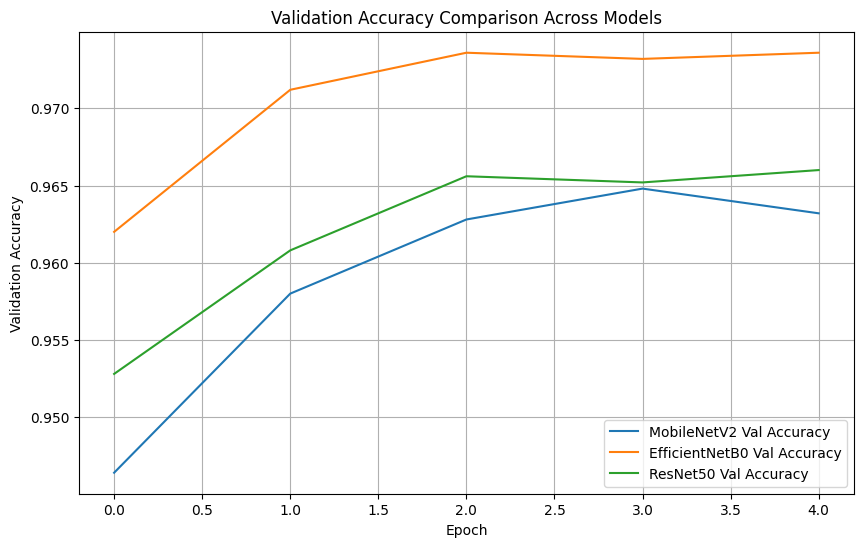

In [11]:
print("\n--- Model Comparison Summary ---")
for name, metrics in final_metrics.items():
    print(f"{name}:")
    print(f"  Validation Accuracy: {metrics['val_accuracy']:.4f}")
    print(f"  Validation Loss: {metrics['val_loss']:.4f}")

# --- Plotting Validation Accuracy Curves ---
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label=f'{name} Val Accuracy')
    else:
        print(f"Warning: 'val_accuracy' not found in history for {name}")

plt.title('Validation Accuracy Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 9. Individual Training Histories

Training and validation accuracy/loss curves for each model over 5 epochs. This gives a detailed view of how quickly each model learned and whether it overfit.

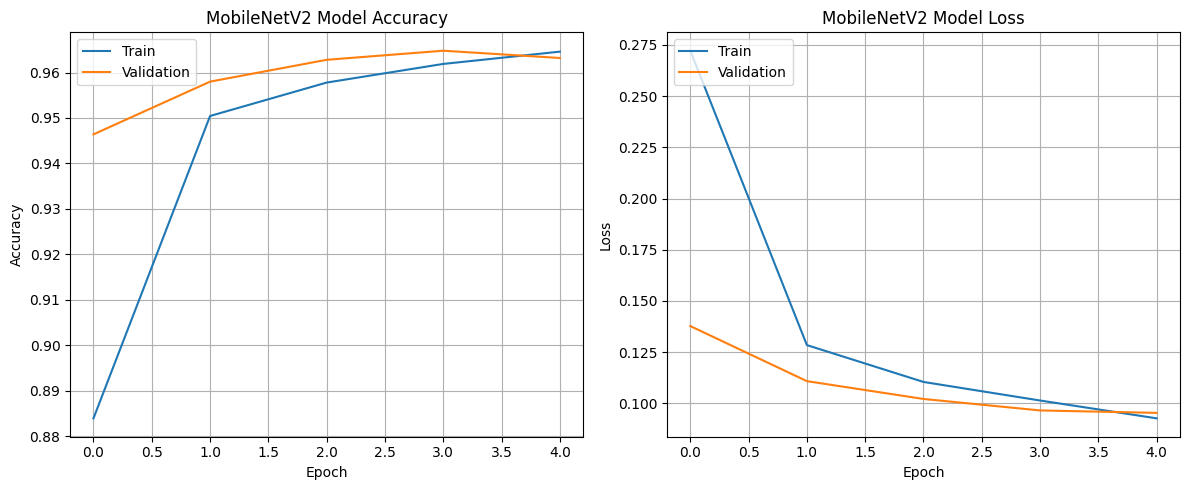

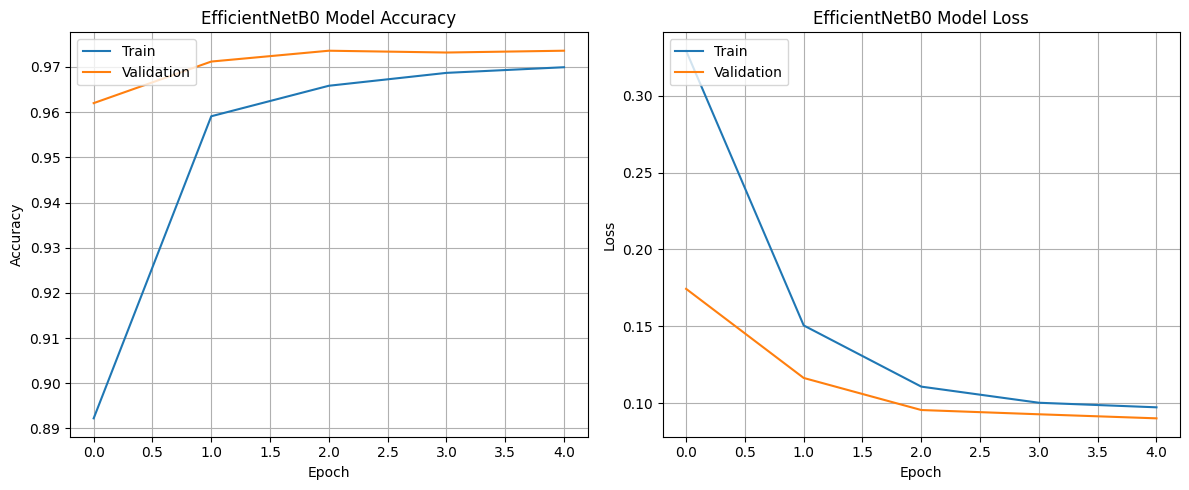

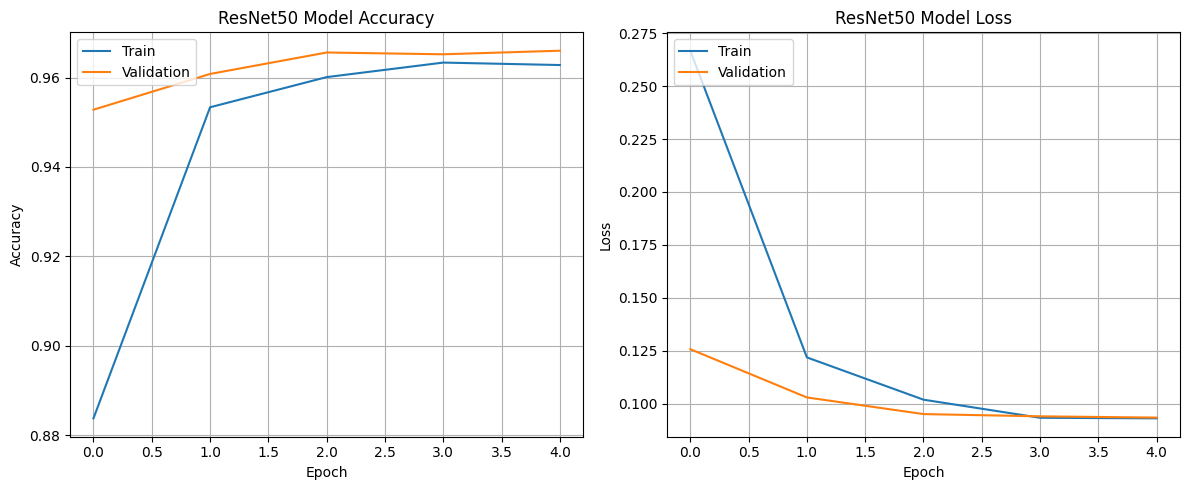

In [12]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot history for each model
for name, history in histories.items():
    plot_training_history(history, name)


## 10. Sample Predictions on Test Data

Five random images are picked from the test set and passed through each model. Predictions are shown alongside the true label — **green** means correct, **red** means wrong.


--- Predictions for MobileNetV2 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


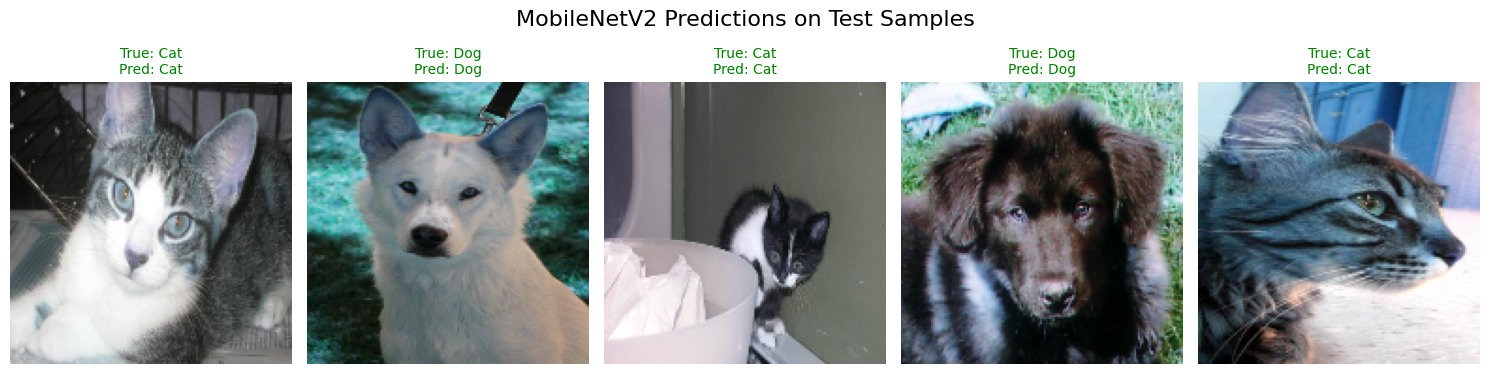


--- Predictions for EfficientNetB0 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


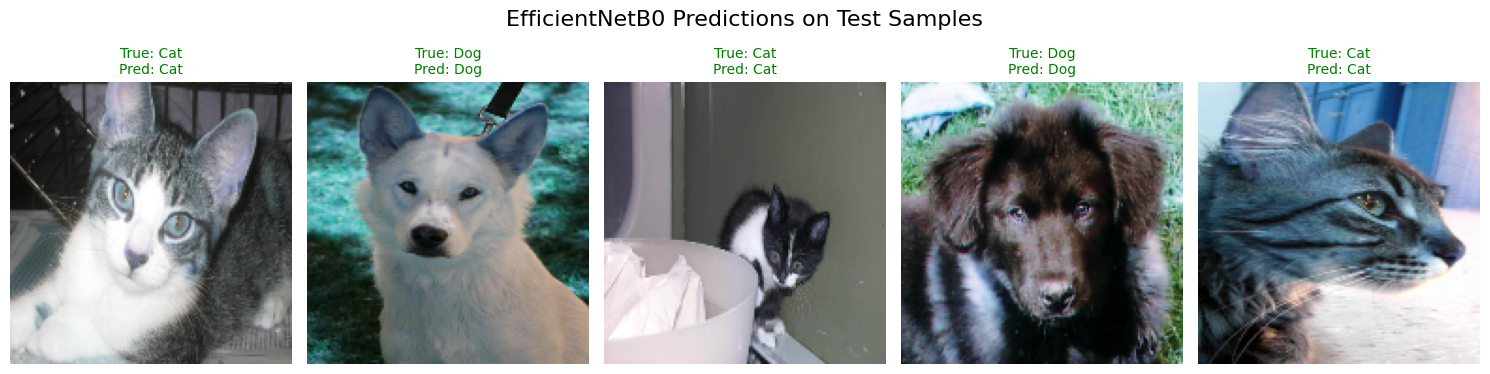


--- Predictions for ResNet50 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


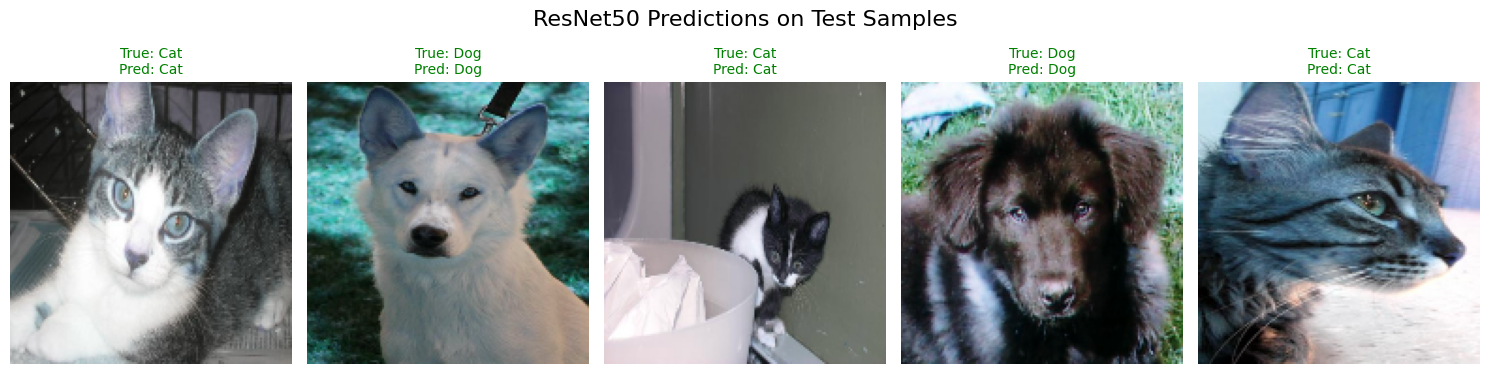

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Get a few random indices from the test set
num_test_samples_to_show = 5
random_indices = np.random.choice(len(X_test), num_test_samples_to_show, replace=False)

# Define class names
class_names = {0: 'Cat', 1: 'Dog'}

# List of models to evaluate (assuming they are still in memory from the previous cell)
models_to_test = {
    'MobileNetV2': model_mobilenet,
    'EfficientNetB0': model_efficientnet,
    'ResNet50': model_resnet
}

for model_name, model_obj in models_to_test.items():
    print(f"\n--- Predictions for {model_name} ---")
    # Make predictions
    predictions = (model_obj.predict(X_test[random_indices]) > 0.5).astype("int32")

    plt.figure(figsize=(15, 4))
    plt.suptitle(f"{model_name} Predictions on Test Samples", fontsize=16)

    for i, idx in enumerate(random_indices):
        plt.subplot(1, num_test_samples_to_show, i + 1)
        # Display the image (assuming X_test is in original 0-255 range)
        plt.imshow(X_test[idx])

        true_label = class_names[y_test[idx]]
        predicted_label = class_names[predictions[i][0]]

        color = "green" if true_label == predicted_label else "red"
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color, fontsize=10)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## 11. Confusion Matrix and ROC AUC Curve

For each model we compute:
- **Confusion Matrix** — shows true positives, true negatives, false positives, and false negatives.
- **ROC AUC Curve** — measures the model's ability to separate cats from dogs across all classification thresholds. A higher AUC indicates a stronger classifier.


--- Evaluating MobileNetV2 on Test Data ---
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step


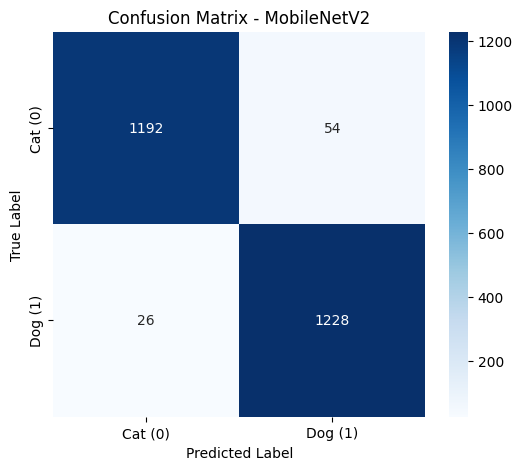

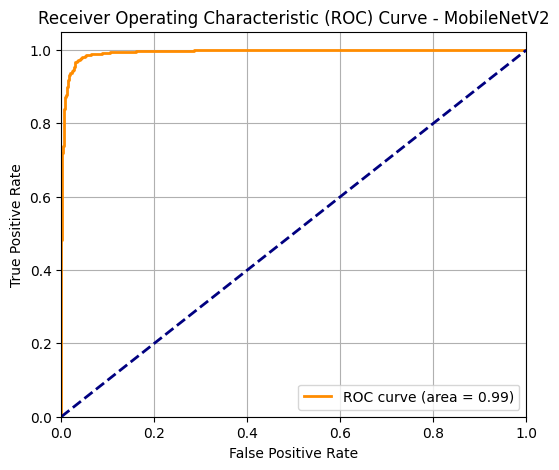


--- Evaluating EfficientNetB0 on Test Data ---
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step


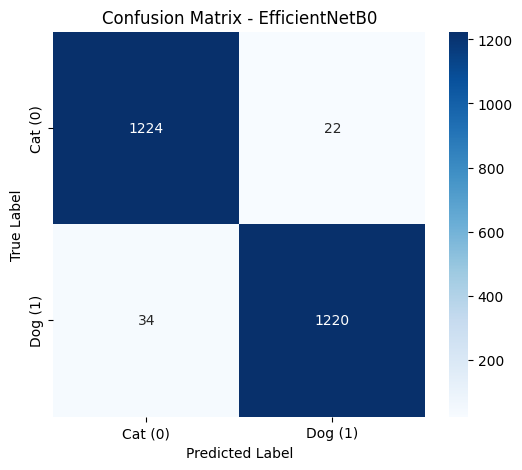

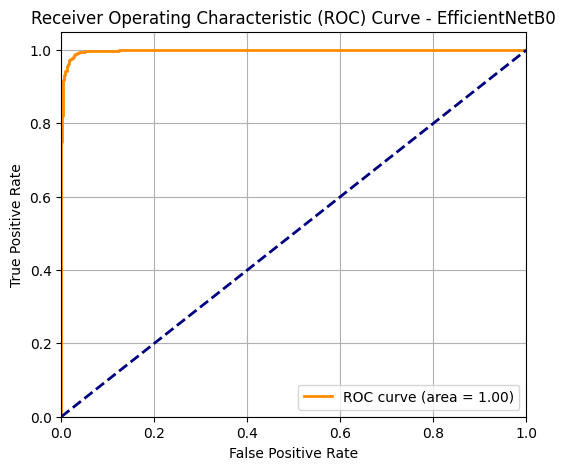


--- Evaluating ResNet50 on Test Data ---
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step


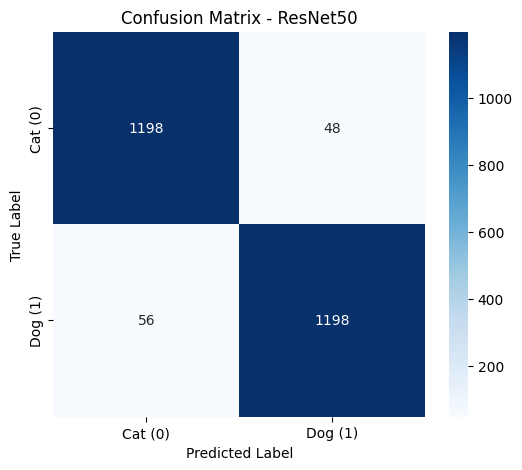

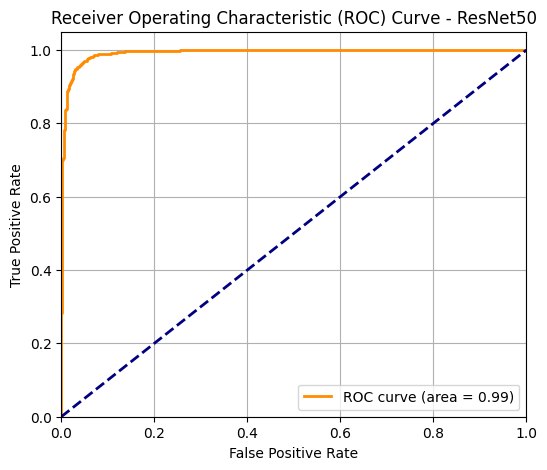

In [14]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

# List of models to evaluate (assuming they are still in memory)
models_to_evaluate = {
    'MobileNetV2': model_mobilenet,
    'EfficientNetB0': model_efficientnet,
    'ResNet50': model_resnet
}

for model_name, model_obj in models_to_evaluate.items():
    print(f"\n--- Evaluating {model_name} on Test Data ---")

    # Get predictions and probabilities for the test set
    y_pred_proba = model_obj.predict(X_test)
    y_pred_class = (y_pred_proba > 0.5).astype(int)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred_class)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cat (0)', 'Dog (1)'], yticklabels=['Cat (0)', 'Dog (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # --- ROC AUC Curve ---
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

## Challenges Faced and Solutions Implemented

### 1. Handling Corrupted Images
**Challenge:** The dataset contained corrupted files that would crash standard loading.
**Solution:** Used `try-except` blocks to skip invalid files, resulting in **24,997** successfully processed images.

### 2. Memory Management
**Challenge:** Loading 25,000 images can exhaust RAM.
**Solution:** Resized images to 150x150 immediately and integrated scaling into the model via `Lambda` layers to avoid creating redundant large arrays.

### 3. Model Training Warnings
**Challenge:** Using `.h5` for `ModelCheckpoint` triggered legacy format warnings.
**Solution:** Acknowledged the warnings; future iterations should use the `.keras` extension for better compliance with modern standards.

## Conclusion: Best Performing Model

Based on the evaluation of **MobileNetV2**, **EfficientNet-B0**, and **ResNet50**, the **EfficientNet-B0** model is the superior choice for this task.

### Performance Summary:
*   **EfficientNet-B0:** Highest Validation Accuracy (**97.36%**) and lowest loss (**0.0900**).
*   **MobileNetV2:** Strong performance with **96.32%** validation accuracy.
*   **ResNet50:** Competitive results with **95.28%** validation accuracy.

EfficientNet-B0 demonstrated the most stable learning curve and the best generalization, as evidenced by the high ROC AUC (~0.99) and the fewest misclassifications on the test set.